# Python Tools

This package contains a collection of functions and classes that I use in multiple projects. There are a number of lines of code that appear time and time again. Thus far I always had to search for them and simply copied them into the new project, resulting in many, sometimes diverging versions. To avoid this, I started collecting them in this package so I can quickly import them.


**Table of Contents**
1. [basics](#tools.basics)
2. [calendar](#calendar)
3. [colors](#colors)
4. [filemanager](#filemanager)
5. [matplotlib](#mplstyle)


## basics

The package `tqdm` provides a nice progress bar, but I prefer a more minimalistic version.


In [1]:
from tools import pbar
import time 

for i in pbar(range(100)):
    time.sleep(0.24)
    if i==50:
        break

  50%|████████████████                | 50/100 (00:12)


Shifting the order of a list is simple but can get annoying to always type out. Therefore it is packed in the following function.

In [2]:
from tools import shift 

lst = [1,2,3,4,5]

print('shift= 1:',shift(lst,1))
print('shift=-1:',shift(lst,-1))

shift= 1: [2, 3, 4, 5, 1]
shift=-1: [5, 1, 2, 3, 4]


## calendar

The `datetime` package already contains most of the functionality of the `Date` class. But always writing out `datetime.date` or `datetime.timedelta` and passing the date in the correct format can be annoying. This package also simplifies some interactions (`int` is assumed to be a `timedelta` in units of days when adding or subtracting it with `Date`).

In [3]:
from tools.calendar import Date

start_date = Date('2024-11-01')
end_date   = Date(2024,11,27)

print(f'{start_date} and {end_date} lie {(end_date-start_date).days} day apart.')

2024-11-01 and 2024-11-27 lie 26 day apart.


The main functionality of this subpackage is to visualize events in a calendar using `matplotlib`. There are a number of templates, depending on the desired range.

We start by creating a calendar for a the specified range. Then we can add events and assign each event a color.

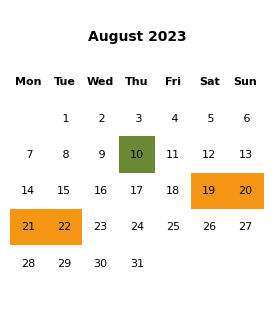

In [4]:
from tools.calendar import MonthCalendar

calendar = MonthCalendar(2023,8)
calendar.add_event('2023-08-10','event1')
for day in range(19,23):
    calendar.add_event(Date(2023,8,day),'event2')
calendar.update_colors({'event1':'#6a8934','event2':'#f69615'})

calendar

If the events cover multiple months, the following format might be more useful.

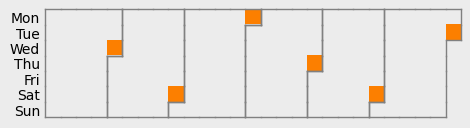

In [5]:
from tools.calendar import WeekCalendar, last_day_of_month

calendar = WeekCalendar(Date('2024-7-01'),Date('2024-12-31'))
for month in range(7,13):
    last_day = last_day_of_month(Date(2024,month,1))
    calendar.add_event(last_day,'last')
calendar.update_colors()
calendar

And finally a yearly calendar

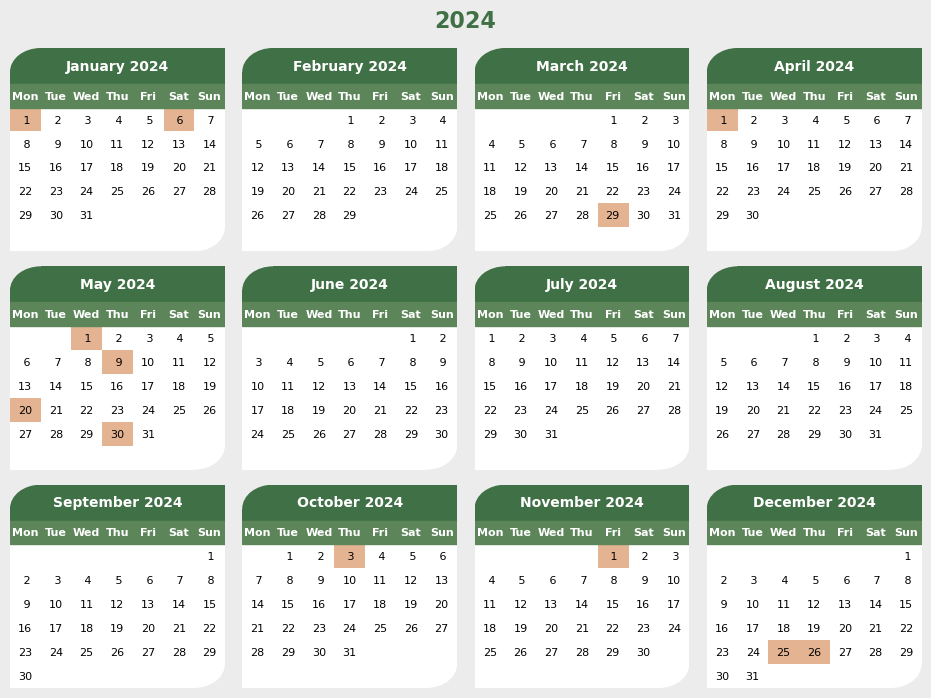

In [6]:
from tools.calendar import YearCalendar

calendar = YearCalendar(2024)
for date in ((1,1),(1,6),(3,29),(4,1),(5,1),(5,9),(5,20),(5,30),(10,3),(11,1),(12,25),(12,26)):
    calendar.add_event(Date(2024,date[0],date[1]),'holiday')
calendar.update_colors({'holiday':'#e4b391'})
fig,ax=calendar.plot()

The style of the plots (maybe with the exception of the `YearCalendar`) are kept rather simple. Since this part differs from project to project anyways, the implementation is more intended as a template that can be copied and then adapted accordingly.

## colors

To define a color in a specific format, we must pass the values to the corresponding class.

In [7]:
from tools.colors import (nameColor, hexColor, rgbColor,
                          cmykColor, hslColor, hsvColor)

rgb = rgbColor((255,215,0))
rgb

rgb(255, 215, 0)

There are a number of classes available and we can create the same color in different formats and the comparison between them returns `True` (For this comparison, each color is converted to RGB and the values are rounded to `int`. Therefore, slightly differing colors might still appear as equal).

In [8]:
name = nameColor('gold')
hexadecimal = hexColor('#ffd700')
rgb = rgbColor((255, 215, 0))
cmyk = cmykColor((0.0, 15.686, 100.0, 0.0))
hsl = hslColor((50.588, 100, 50))
hsv = hsvColor((50.588, 100, 100))

# when compared, the rgb value is used
name==hexadecimal==rgb==cmyk==hsl==hsv

True

It quickly becomes annoying to always remember to pass the different formats to the appropriate class. `to_color()` provides a factory function that takes care of this and tries to identify the correct format. If a suitable format is found, the input is passed on and an instance of the corresponding class is returned. Below are a few examples with valid inputs.

In [9]:
from tools.colors import to_color

color1 = to_color('gold')
color2 = to_color('#ffd700')
color3 = to_color(hex='#ffd700')
color4 = to_color((255, 215, 0))
color5 = to_color(rgb=(255, 215, 0))
color6 = to_color(r=255,g=215,b=0)
color7 = to_color(h=51,s=100,v=100)
color8 = to_color('hsv(50°, 100%, 100%)')
color9 = to_color(hsl=(50.59,100,50))

# it can even guess strings 
to_color('hsl(50.59°, 100%, 50%)')

hsl(51°, 100%, 50%)

The main purpose of the package is to compare colors side by side and to find well-matching collections. `ColorPalette` is a `list` subclass that makes it easy to collect colors and visualize them side by side.

In [10]:
from tools.colors import ColorPalette

ColorPalette(['#80957f','#76616e','#a76277','#d07d7e','#e4b391'])

['#80957f', '#76616e', '#a76277', '#d07d7e', '#e4b391']

In addition, this class offers some useful methods that facilitate the creation of beautiful palettes. Instead of defining all colors by hand, we can also pass two colors and calculate a gradient in the RGB or HSV color space. For the latter, we can chose whether to take the short or the long route around the color wheel (for the hue value).

In [11]:
color1 = to_color('#de5437')
color2 = to_color('#00aced')
ColorPalette.rgb_gradient(color1,color2,steps=10)

[rgb(222, 84, 55),
 rgb(197, 94, 75),
 rgb(173, 104, 95),
 rgb(148, 113, 116),
 rgb(123, 123, 136),
 rgb(99, 133, 156),
 rgb(74, 143, 176),
 rgb(49, 152, 197),
 rgb(25, 162, 217),
 rgb(0, 172, 237)]

In [12]:
ColorPalette.hsv_gradient(color1,color2,steps=10,direction='short')

[rgb(222, 84, 55),
 rgb(224, 49, 75),
 rgb(225, 43, 129),
 rgb(227, 37, 188),
 rgb(206, 31, 229),
 rgb(141, 25, 230),
 rgb(70, 19, 232),
 rgb(13, 31, 234),
 rgb(6, 99, 235),
 rgb(0, 172, 237)]

In [13]:
ColorPalette.hsv_gradient(color1,color2,steps=10,direction='long')

[rgb(222, 84, 55),
 rgb(224, 140, 49),
 rgb(225, 200, 43),
 rgb(188, 227, 37),
 rgb(120, 229, 31),
 rgb(47, 230, 25),
 rgb(19, 232, 70),
 rgb(13, 234, 142),
 rgb(6, 235, 219),
 rgb(0, 172, 237)]

We can also extract the colors from the colormaps defined in `matplotlib`.

In [14]:
ColorPalette.from_matplotlib('viridis',N=16)

[rgb(68, 1, 84),
 rgb(72, 25, 107),
 rgb(70, 47, 124),
 rgb(64, 67, 135),
 rgb(56, 86, 139),
 rgb(48, 103, 141),
 rgb(41, 120, 142),
 rgb(35, 136, 141),
 rgb(30, 152, 138),
 rgb(34, 167, 132),
 rgb(53, 183, 120),
 rgb(83, 197, 103),
 rgb(121, 209, 81),
 rgb(165, 218, 53),
 rgb(210, 225, 27),
 rgb(253, 231, 36)]

## filemanager

Get properties of a file like size or a unique ID.

## mplstyle

Templates for the style of `matplotlib` plots.

# Installation

This package can be installed in the current environment with

```bash
pip install -e .
```

This ensures that changes to the code make it to the working projects.

Since this project also serves as a kind of notebook, here are some other handy notes. This notebook can be converted to `ReadMe.md` with
```bash
jupyter nbconvert --execute --to markdown ReadMe.ipynb
```

To push this repository from the command line use

```bash
git remote add origin https://github.com/fschmnn/tools.git
git branch -M main
git push -u origin main
```

